## About Dataset


### Context


##### - "Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

#### Content


#### Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

#### The data set includes information about:

#### Customers who left within the last month – the column is called Churn
#### Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
#### Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
#### Demographic info about customers – gender, age range, and if they have partners and dependents

## Exploration & Data Loading

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/home/suman/Documents/intern_project/customer_churn_prediction/data/raw/dataset.csv")
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
import mlflow
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

MLFLOW_DB = os.path.join(project_root,"mlflow.db")
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB}")
mlflow.set_experiment("Telco Churn - Development")

/home/suman/Documents/intern_project/customer_churn_prediction/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Experiment: artifact_location='/home/suman/Documents/intern_project/customer_churn_prediction/notebooks/mlruns/1', creation_time=1787189142927, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787189142927, lifecycle_stage='active', name='Telco Churn - Development', tags={}, trace_location=None, workspace='default'>

In [5]:
df.describe(include="all")
df["Contract"].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

#### -based on the .describe, we can see that most categorical variables have between 2,3,0r 4 categories
#### -for 2 categories, we can use binary encoding
#### -for categories>2, we can use one-hot encoding 

In [6]:
df["SeniorCitizen"]
df["StreamingTV"].value_counts()

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

# Binary Encoding

In [7]:
#binary cols-Contains two unique values

binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']

df[binary_cols] = df[binary_cols].replace(
    {
        "Yes":1,"No":0,
        "Male":1,"Female":0
    }
)

df[binary_cols] = df[binary_cols].astype(int)


/tmp/ipykernel_10179/1457545482.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace(


In [8]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

## One-Hot encoding 

In [9]:
# Categorical columns with > 2 unique values
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

df = pd.get_dummies(df,columns=multi_cat_cols,drop_first=True)
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

# Data Cleaning 

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
print(df['TotalCharges'].isna().sum())

11


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   PaperlessBilling                       7043 non-null   int64  
 8   MonthlyCharges                         7043 non-null   float64
 9   TotalCharges                           7032 non-null   float64
 10  Churn                                  7043 non-null   int64  
 11  Mult

In [12]:
df =df.drop('customerID',axis=1)

In [13]:
bools = df.select_dtypes(include='bool').columns
df[bools] = df[bools].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [14]:
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)


Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


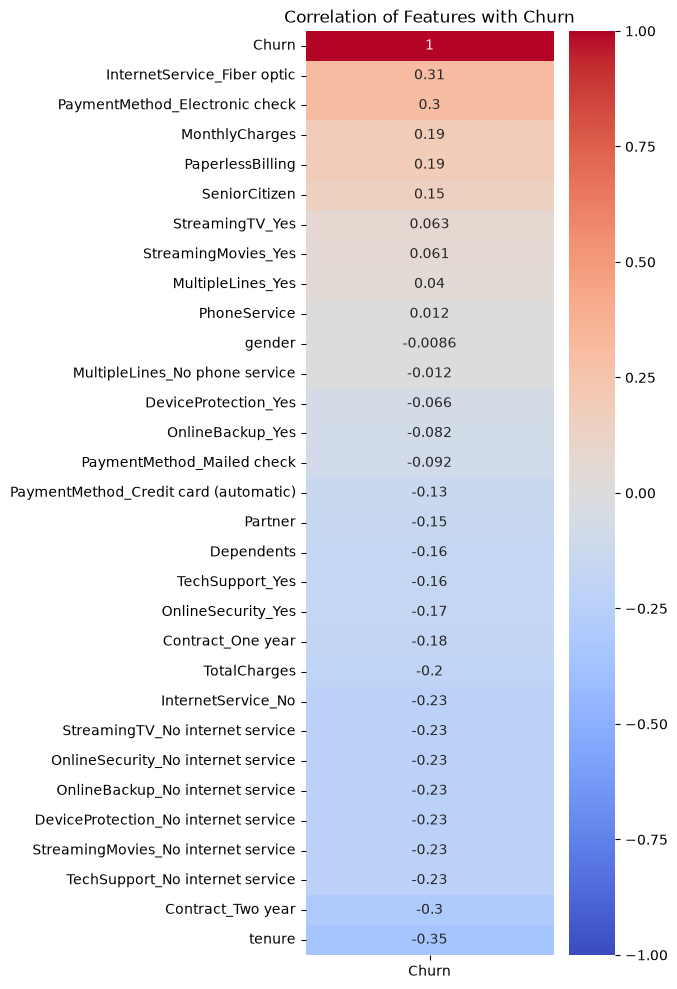

In [15]:
# Compute correlation matrix only for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Focus on correlation with Churn
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# Plot heatmap
plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()

### Correlation with Churn

**Negative (higher value → less likely to churn):**

- **tenure (-0.35)** → Customers who stay longer are less likely to churn.
- **Contract_Two year (-0.30)** → Customers on long-term contracts churn much less.
- **Contract_One year (-0.18)** → Same trend, but weaker than two-year contracts.

**Positive (higher value → more likely to churn):**

- **InternetService_Fiber optic (+0.31)** → Fiber optic users show a higher churn rate in this dataset.
- **PaymentMethod_Electronic check (+0.30)** → Customers using electronic checks show a higher churn rate.

# Look for multi-colinearity

In [16]:
# We need to collapse redundant columns before running VIF

df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)


# # Drop the original redundant dummies
drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)

if "MultipleLines_No phone service" in df.columns:
    print("Inside the if statement")
    df["No_phone_service"] = df["MultipleLines_No phone service"].astype(int)
    df = df.drop(columns=["MultipleLines_No phone service"])
df["No_phone_service"]
df.columns

Inside the if statement


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'No_internet_service', 'No_phone_service'],
      dtype='object')

# Remove the original target 

In [17]:
X = df.drop(columns=["Churn"])
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

#### Run VIF

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values,i)for i in range(X_vif.shape[1])]

vif_data = vif_data.sort_values(by="VIF",ascending=False)
print(vif_data)


/home/suman/Documents/intern_project/customer_churn_prediction/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/home/suman/Documents/intern_project/customer_churn_prediction/.venv/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature         VIF
6                            PhoneService         inf
12                     InternetService_No         inf
24                    No_internet_service         inf
25                       No_phone_service         inf
8                          MonthlyCharges  866.089640
11            InternetService_Fiber optic  148.500814
18                    StreamingMovies_Yes   24.156394
17                        StreamingTV_Yes   24.080019
9                            TotalCharges   10.811490
5                                  tenure    7.584453
10                      MultipleLines_Yes    7.289761
15                   DeviceProtection_Yes    6.924754
14                       OnlineBackup_Yes    6.796678
16                        TechSupport_Yes    6.476508
13                     OnlineSecurity_Yes    6.338349
20                      Contract_Two year    2.652328
22         PaymentMethod_Electronic check    1.976032
23             PaymentMethod

In [19]:
print((df["No_phone_service"] == (1 - df["PhoneService"])).all())
print((df["No_internet_service"] ==  df["InternetService_No"]).sum())

True
7043


In [20]:
df = df.drop(
    columns=[
        "No_internet_service",
        "No_phone_service"
    ]
)



#### - I find the redundency in the features, i investigate and prove it, and thus decide to drop one column and keep the other
#### -Clearly we can see there's multicolinearity between features
#### -So either we need to drop some features or use regularization techniques like Lasso or Ridge regression to handle this
#### -Or use tree based models which are less sensitive to multicollinearity In decision trees, splits are based on feature importance for reducing impurity — redundant features just compete, but won’t cause unstable predictions.

# Train Model

## Machine Learning

In [21]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

#### Business Perspective

#### It's a classification problem and churn prediction model,the business doesn't want to lose the customer
#### Metrices like Recall and Precision matter more than accuracy, because the class is imbalanced and accuracy can make the model dumb


In [22]:
#Positive class
P = (df["Churn"].sum()) 
P = P *100 / len(df["Churn"]) 
#Negative class
N = 100 - P
print("Positive Class: ",P)
print("Negative Class: ",N)

#The imbalance isnot that huge, so class weighting and threshold tuning can probably solve the issue
# no need to generate synthetic data, undersampling or oversampling 

Positive Class:  26.536987079369588
Negative Class:  73.4630129206304


## Typical priority
- #### If retention campaigns are cheap → prioritize recall (catch every possible churner).
- #### If retention campaigns are expensive → balance precision and recall using F1 score or a precision-recall trade-off.
- #### If business wants a ranking of churn risk → use ROC-AUC or PR-AUC to evaluate the model.

In [23]:
from sklearn.model_selection import train_test_split
import pandas as pd
import time

In [24]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

#Random state 42 gives the same split everytime i run the script, so there is stability
X_train,X_temp,y_train,y_temp = train_test_split(X,y,random_state=42,stratify=y,test_size=0.4)

X_val,X_test,y_val,y_test = train_test_split(X_temp,y_temp,random_state=42,stratify=y_temp,test_size=0.5)

THRESHOLD = 0.3 #To boost the recall, tradeoff is lower precision

# Train RandomForestClassifier

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

r_f = RandomForestClassifier(
    n_estimators = 300,
    class_weight = "balanced",
    random_state = 42,
    n_jobs = -1    
)

r_f.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [26]:
proba = r_f.predict_proba(X_val)[:,1]
y_pred = (proba >=THRESHOLD).astype(int)
print(classification_report(y_true=y_val,y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.93      0.65      0.76      1035
           1       0.47      0.86      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.71      0.72      1409



In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score
# [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
print("Threshold | Precision | Recall | f1_score")

for threshold in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred = (proba>threshold).astype(int)
    
    recall = recall_score(y_true=y_val,y_pred=y_pred)
    precision = precision_score(y_true=y_val,y_pred=y_pred)
    f1_ = f1_score(y_true=y_val,y_pred=y_pred)
    
    print(f"{threshold:<8.3f} | {precision:<8.3f} | {recall:<8.3f} | {f1_:<8.3f}")
    

Threshold | Precision | Recall | f1_score
0.250    | 0.443    | 0.901    | 0.594   
0.300    | 0.472    | 0.848    | 0.606   
0.350    | 0.501    | 0.802    | 0.617   
0.400    | 0.523    | 0.754    | 0.618   
0.450    | 0.563    | 0.706    | 0.626   
0.500    | 0.595    | 0.655    | 0.623   


- #### The precision recall tradeoff, they have a negative co-relation, and based on stakeholders, we chose the tradeoffs. 
- #### With lower threshold, catching more numbers of churners, but flagging more customers, and vice versa

## LightBGM Clssifier

In [28]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

In [29]:
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Training timer
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = lgbm.predict_proba(X_val)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_val, y_pred, digits=3))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1121, number of negative: 3104
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.089677 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 4225, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
⏱ Training time: 1.74 seconds
⏱ Prediction time: 0.0084 seconds
              precision    recall  f1-score   support

           0      0.907     0.717     0.801      1035
           1      0.504     0.797     0.618       374

    accuracy                          0.738      1409
   macro avg      0.706     0.757     0.709      1409
weighted avg      0.800     0.

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = lgbm.predict_proba(X_val)[:, 1]

print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_val, preds, pos_label=1)
    rec = recall_score(y_val, preds, pos_label=1)
    f1 = f1_score(y_val, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.483   0.824   0.609   
0.3     0.504   0.797   0.618   
0.35    0.512   0.767   0.614   
0.4     0.524   0.735   0.612   
0.45    0.538   0.711   0.613   
0.5     0.560   0.682   0.615   


# XgBoost Classifier

In [31]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_val)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_val, y_pred, digits=3))

⏱ Training time: 2.70 seconds
⏱ Prediction time: 0.0258 seconds
              precision    recall  f1-score   support

           0      0.902     0.695     0.785      1035
           1      0.484     0.791     0.600       374

    accuracy                          0.720      1409
   macro avg      0.693     0.743     0.693      1409
weighted avg      0.791     0.720     0.736      1409



In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = xgb.predict_proba(X_val)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_val, preds, pos_label=1)
    rec = recall_score(y_val, preds, pos_label=1)
    f1 = f1_score(y_val, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")  

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.471   0.834   0.602   
0.3     0.484   0.791   0.600   
0.35    0.516   0.775   0.620   
0.4     0.529   0.735   0.615   
0.45    0.549   0.695   0.613   
0.5     0.559   0.655   0.603   


## Model Decision

- ### Need to choose the model based on the business decision
- ### For now I am choosing the model that gives me higher recall good enough preicision
- ### Final Decision -Random Forest Classifier(With Threshold - 0.25, Precision - 0.456, Recall - 0.912)

# Log the baseline Random Forest Classifier

In [33]:
import mlflow
from sklearn.metrics import(precision_score,recall_score,f1_score,average_precision_score)

#prediction on the validation set
predict_proba = r_f.predict_proba(X_val)[:,1]
val_pred = (predict_proba>= THRESHOLD).astype(int)

# metrics
val_precision = precision_score(y_val, val_pred)
val_recall = recall_score(y_val, val_pred)
val_f1 = f1_score(y_val, val_pred)
val_auprc = average_precision_score(y_val,predict_proba )
print(val_auprc)

r_f = RandomForestClassifier(
    n_estimators = 300,
    class_weight = "balanced",
    random_state = 42,
    n_jobs = -1    
)


with mlflow.start_run(run_name="Random Forest baseline model"):
    #-------------------
    # Parameters
    # ------------------
    
    mlflow.log_params(
        {
            "model_type": "RandomForestClassifier",
            "n_estimators": 300,
            "random_state": 42,
            "class_weight": "balanced",
            "n_jobs": -1,
            "threshold": 0.30
        }
    )
    
    # -------------------------
    # Validation metrics
    # -------------------------
    
    mlflow.log_metrics({
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1,
        "val_auprc": val_auprc
    })
    
    # -------------------------
    # Tags
    # -------------------------
    mlflow.set_tag("stage", "development")
    mlflow.set_tag("run_type", "baseline")

0.626219790743167


# Hyperparameter Tuning(Optuna) & Experiment Tracking(Mlflow)

In [34]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split

#Objective function for optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            20
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            20
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),

        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train,y_train)
    proba = model.predict_proba(X_val)[:,1]
    y_pred = (proba >= THRESHOLD).astype(int)
    return recall_score(y_val, y_pred, pos_label=1) 

#Run optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=30)

print("Best Params:",study.best_params)
print("Best Recall:",study.best_value)

[I 2026-08-21 17:13:13,297] A new study created in memory with name: no-name-09b97ca7-fa14-4334-8ffd-c9a1ab688af7
[I 2026-08-21 17:13:13,793] Trial 0 finished with value: 0.9491978609625669 and parameters: {'n_estimators': 331, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 0 with value: 0.9491978609625669.
[I 2026-08-21 17:13:14,053] Trial 1 finished with value: 0.9331550802139037 and parameters: {'n_estimators': 164, 'max_depth': 11, 'min_samples_split': 18, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9491978609625669.
[I 2026-08-21 17:13:14,260] Trial 2 finished with value: 0.93048128342246 and parameters: {'n_estimators': 130, 'max_depth': 11, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9491978609625669.
[I 2026-08-21 17:13:14,830] Trial 3 finished with value: 0.9438502673796791 and parameters: {'n_estimators': 384, 'max_depth': 7, 'min_s

Best Params: {'n_estimators': 482, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'log2'}
Best Recall: 0.9919786096256684


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import time

# Add the scale_pos_weight and fixed params to the best ones from Optuna
best_params = study.best_params
print(best_params)
best_params.update(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
print(best_params)

{'n_estimators': 482, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'log2'}
{'n_estimators': 482, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'log2', 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}


# Train the testing set with the best parameters found

In [36]:
rf_model = RandomForestClassifier(**best_params)
#Training timer
start_train = time.time()
rf_model.fit(X_test,y_test)
train_time = time.time()-start_train
print(f"Training time:{train_time:.2f} seconds")

#Prediction timer
start_predict = time.time()
predict_proba = rf_model.predict_proba(X_test)[:,1]
y_pred = (predict_proba>=THRESHOLD).astype(int)
pred_time = time.time() - start_predict
print(f"Prediction time:{pred_time:.2f} seconds")

#classification report
print(classification_report(y_true=y_test,y_pred = y_pred))



Training time:0.56 seconds
Prediction time:0.07 seconds
              precision    recall  f1-score   support

           0       0.99      0.35      0.52      1035
           1       0.36      0.99      0.52       374

    accuracy                           0.52      1409
   macro avg       0.67      0.67      0.52      1409
weighted avg       0.82      0.52      0.52      1409



# Precision recall curve from validation set

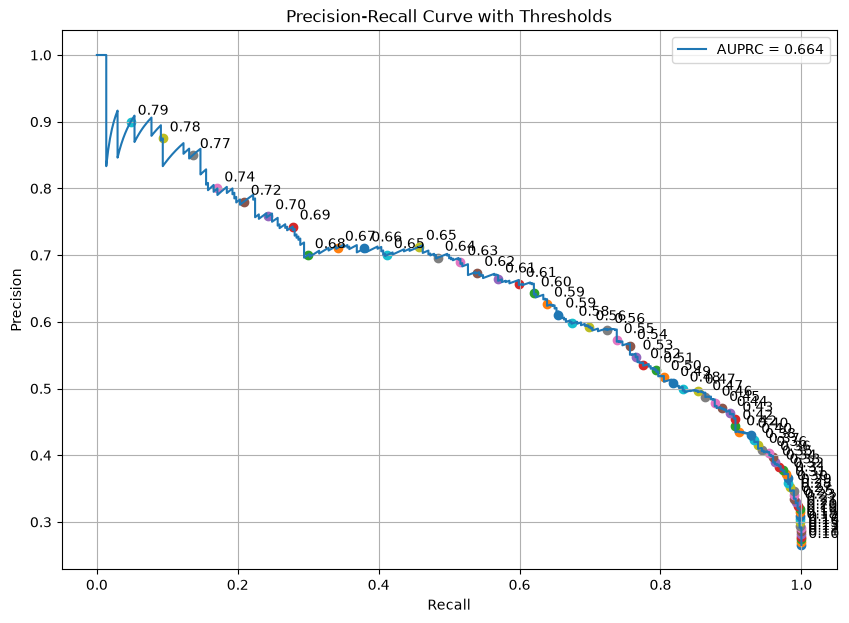

In [37]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

val_proba = rf_model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_val,
    val_proba
)

auprc = average_precision_score(y_val, val_proba)

plt.figure(figsize=(10, 7))

plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")

# Show threshold labels on selected points
step = 20

for i in range(0, len(thresholds), step):
    plt.scatter(recall[i], precision[i])

    plt.annotate(
        f"{thresholds[i]:.2f}",
        (recall[i], precision[i]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve with Thresholds")
plt.legend()
plt.grid()

plt.show()

## Log the params into mlflow


In [38]:
import mlflow
from sklearn.ensemble import RandomForestClassifier # or mlflow.xgboost
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
import time
import os

# Force MLflow to always use the project root's mlruns folder
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

with mlflow.start_run(run_name="Random Forest parameter tuned model"):

    # Log parameters
    mlflow.log_params(best_params)

    # Training timer
    start_train = time.time()
    rf_model = RandomForestClassifier(**best_params)
    rf_model.fit(X_train, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)

    # Prediction
    start_pred = time.time()
    proba = rf_model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)

    # Metrics
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, proba)

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)


In [39]:
import os
import pandas as pd
import mlflow
import mlflow.sklearn

TRACKING_URI = "http://127.0.0.1:5000/"
RUN_ID = "b70b388fb0394aceb636311f9b50199b"

mlflow.set_tracking_uri(TRACKING_URI)

MODEL_URI = f"runs:/{RUN_ID}/model"

pipeline = mlflow.sklearn.load_model(MODEL_URI)

print(type(pipeline))
print(pipeline)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBil